In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Validação
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Modelos de Regressão (Parte 1)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Modelos de Classificação (Parte 2)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore', module='pandas')

--- STUDENT PERFORMANCE (REGRESSÃO) ---
Shape do treino: (395, 31)
Shape do teste: (40, 30)


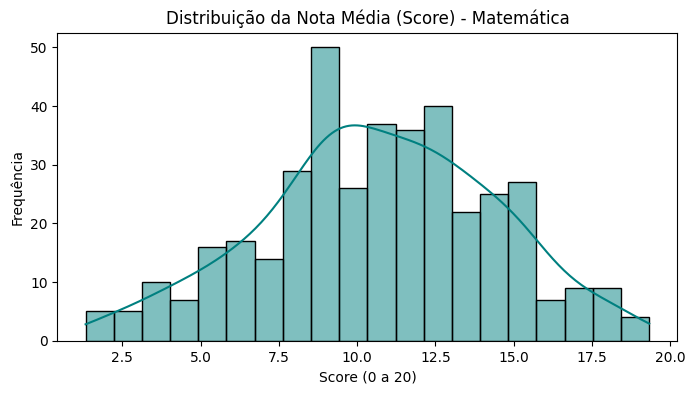

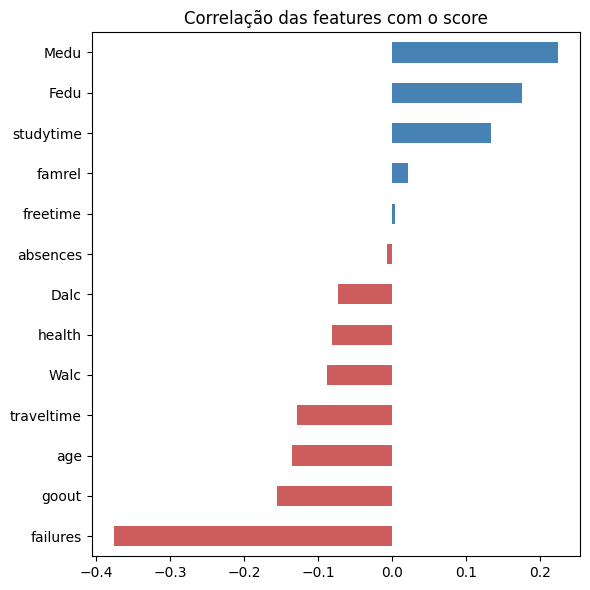

In [8]:

# ==========================================
# 1.1 CARGA E EDA - REGRESSÃO (STUDENT)
# ==========================================
df_train_reg = pd.read_csv('regressao/train.csv')
df_test_reg = pd.read_csv('regressao/test.csv')

print("--- STUDENT PERFORMANCE (REGRESSÃO) ---")
print(f"Shape do treino: {df_train_reg.shape}")
print(f"Shape do teste: {df_test_reg.shape}")

plt.figure(figsize=(8, 4))
sns.histplot(df_train_reg['score'], bins=20, kde=True, color='teal')
plt.title('Distribuição da Nota Média (Score) - Matemática')
plt.xlabel('Score (0 a 20)')
plt.ylabel('Frequência')
plt.show()

num_cols_reg = df_train_reg.select_dtypes(include=['int64', 'float64']).columns.drop('score')
corr_score = df_train_reg[num_cols_reg].corrwith(df_train_reg['score']).sort_values()

plt.figure(figsize=(6, 6))
corr_score.plot(kind='barh', color=(corr_score > 0).map({True: 'steelblue', False: 'indianred'}))
plt.title('Correlação das features com o score')
plt.tight_layout()
plt.show()

# ==========================================
# 1.2 PRÉ-PROCESSAMENTO - REGRESSÃO
# ==========================================
X_reg = df_train_reg.drop(columns=['score'])
y_reg = df_train_reg['score']

# Identificando colunas de texto para aplicar One-Hot Encoding
cat_cols = X_reg.select_dtypes(include=['object', 'string']).columns

X_reg_encoded = pd.get_dummies(X_reg, columns=cat_cols, drop_first=True)
X_test_reg_encoded = pd.get_dummies(df_test_reg, columns=cat_cols, drop_first=True)

# Alinhamento crítico: garante que o conjunto de teste tenha as exatas colunas do treino
X_test_reg_encoded = X_test_reg_encoded.reindex(columns=X_reg_encoded.columns, fill_value=0)

# Divisão de Validação Interna (80% treino, 20% validação)
X_tr_r, X_val_r, y_tr_r, y_val_r = train_test_split(
    X_reg_encoded, y_reg, test_size=0.2, random_state=42
)

In [9]:
# ==========================================
# 1.3 e 1.4 MODELAGEM E AVALIAÇÃO - REGRESSÃO
# ==========================================
modelos_regressao = {
    "Regressão Linear": LinearRegression(),
    "Ridge (Regularizada)": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

print("Comparação de RMSE na Validação (Regressão):")
melhor_modelo_reg = None
menor_rmse = float('inf')

for nome, modelo in modelos_regressao.items():
    modelo.fit(X_tr_r, y_tr_r)
    y_pred = modelo.predict(X_val_r)
    rmse = np.sqrt(mean_squared_error(y_val_r, y_pred))
    print(f"{nome}: {rmse:.4f}")
    
    # Salvando o modelo que tiver o menor erro para a submissão final
    if rmse < menor_rmse:
        menor_rmse = rmse
        melhor_modelo_reg = modelo

print(f"\nModelo escolhido para submissão: {melhor_modelo_reg.__class__.__name__}")

Comparação de RMSE na Validação (Regressão):
Regressão Linear: 3.3750
Ridge (Regularizada): 3.3681
Random Forest: 3.3347

Modelo escolhido para submissão: RandomForestRegressor



--- BREAST CANCER (CLASSIFICAÇÃO) ---
Distribuição das Classes (Alvo):
diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64

Valores nulos no treino: 0
Valores nulos no teste: 0


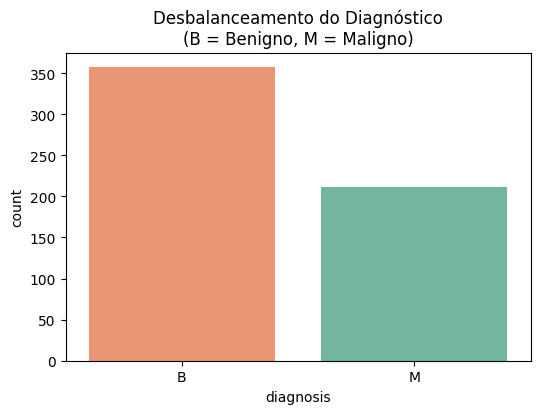

In [10]:
# ==========================================
# 2.1 CARGA E EDA - CLASSIFICAÇÃO (BREAST CANCER)
# ==========================================
df_train_clf = pd.read_csv('classiicacao/train2.csv')
df_test_clf = pd.read_csv('classiicacao/test2.csv')

print("\n--- BREAST CANCER (CLASSIFICAÇÃO) ---")
print("Distribuição das Classes (Alvo):")
print(df_train_clf['diagnosis'].value_counts(normalize=True))

print(f"\nValores nulos no treino: {df_train_clf.isna().sum().sum()}")
print(f"Valores nulos no teste: {df_test_clf.isna().sum().sum()}")

plt.figure(figsize=(6, 4))
sns.countplot(data=df_train_clf, x='diagnosis', hue='diagnosis', palette='Set2', order=['B', 'M'], legend=False)
plt.title('Desbalanceamento do Diagnóstico\n(B = Benigno, M = Maligno)')
plt.show()

# ==========================================
# 2.2 PRÉ-PROCESSAMENTO - CLASSIFICAÇÃO
# ==========================================
X_clf = df_train_clf.drop(columns=['diagnosis'])
y_clf = df_train_clf['diagnosis']


scaler = StandardScaler()
X_clf_scaled = scaler.fit_transform(X_clf)
X_test_clf_scaled = scaler.transform(df_test_clf)


X_tr_c, X_val_c, y_tr_c, y_val_c = train_test_split(
    X_clf_scaled, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

Comparação de Acurácia na Validação (Classificação):
Regressão Logística: 0.9649
KNN (k=5): 0.9561
Random Forest: 0.9737

Modelo escolhido para submissão: RandomForestClassifier


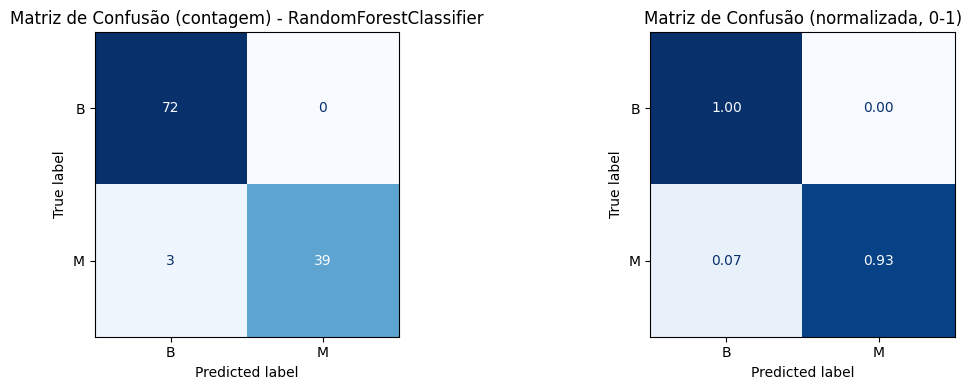

Verdadeiros negativos (B previsto certo): 72
Falsos positivos (B real, previsto M):     0
Falsos negativos (M real, previsto B):     3  <- erro mais grave clinicamente
Verdadeiros positivos (M previsto certo):  39

Em proporção (diagonal normalizada): recall de B = 1.00, recall de M = 0.93.

Interpretação: o falso negativo é o erro que mais importa aqui, pois significa classificar um tumor maligno como benigno (deixar de tratar um câncer). Mesmo com acurácia alta, vale monitorar especificamente essa célula da matriz.


In [11]:
# ==========================================
# 2.3 e 2.4 MODELAGEM E AVALIAÇÃO - CLASSIFICAÇÃO
# ==========================================
modelos_classificacao = {
    "Regressão Logística": LogisticRegression(random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(random_state=42)
}

print("Comparação de Acurácia na Validação (Classificação):")
melhor_modelo_clf = None
maior_acc = 0

for nome, modelo in modelos_classificacao.items():
    modelo.fit(X_tr_c, y_tr_c)
    y_pred = modelo.predict(X_val_c)
    acc = accuracy_score(y_val_c, y_pred)
    print(f"{nome}: {acc:.4f}")
    
    if acc > maior_acc:
        maior_acc = acc
        melhor_modelo_clf = modelo

print(f"\nModelo escolhido para submissão: {melhor_modelo_clf.__class__.__name__}")


y_pred_best = melhor_modelo_clf.predict(X_val_c)

# Matriz de confusão em contagem absoluta (para os TN/FP/FN/TP)
cm_counts = confusion_matrix(y_val_c, y_pred_best, labels=melhor_modelo_clf.classes_)

# Matriz de confusão normalizada por linha (recall por classe),
# assim a diagonal fica em valores entre 0 e 1, como pedido no tarefa.md
cm_norm = confusion_matrix(
    y_val_c, y_pred_best, labels=melhor_modelo_clf.classes_, normalize='true'
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

disp_counts = ConfusionMatrixDisplay(
    confusion_matrix=cm_counts, display_labels=melhor_modelo_clf.classes_
)
disp_counts.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f"Matriz de Confusão (contagem) - {melhor_modelo_clf.__class__.__name__}")

disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm, display_labels=melhor_modelo_clf.classes_
)
disp_norm.plot(cmap='Blues', ax=axes[1], colorbar=False, values_format='.2f')
axes[1].set_title("Matriz de Confusão (normalizada, 0-1)")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(
    y_val_c, y_pred_best, labels=['B', 'M']
).ravel()

print(f"Verdadeiros negativos (B previsto certo): {tn}")
print(f"Falsos positivos (B real, previsto M):     {fp}")
print(f"Falsos negativos (M real, previsto B):     {fn}  <- erro mais grave clinicamente")
print(f"Verdadeiros positivos (M previsto certo):  {tp}")
print(
    f"\nEm proporção (diagonal normalizada): "
    f"recall de B = {cm_norm[0,0]:.2f}, recall de M = {cm_norm[1,1]:.2f}."
)
print(
    "\nInterpretação: o falso negativo é o erro que mais importa aqui, pois "
    "significa classificar um tumor maligno como benigno (deixar de tratar "
    "um câncer). Mesmo com acurácia alta, vale monitorar especificamente essa "
    "célula da matriz."
)

In [12]:
# ==========================================
# 3. GERAÇÃO DE ARQUIVOS PARA O KAGGLE
# ==========================================

# Previsão Final - Regressão
test_preds_reg = melhor_modelo_reg.predict(X_test_reg_encoded)
test_preds_reg = np.clip(test_preds_reg, 0, 20) 
sub_reg = pd.DataFrame({
    'id': df_test_reg.index,
    'score': np.round(test_preds_reg, 2)
})

# Previsão Final - Classificação
# Formato pedido no tarefa.md: diagnosis como 0/1 (M = maligno = 1, B = benigno = 0)
test_preds_clf = melhor_modelo_clf.predict(X_test_clf_scaled)
diag_map = {'M': 1, 'B': 0}
test_preds_clf_bin = pd.Series(test_preds_clf).map(diag_map).astype(int)
sub_clf = pd.DataFrame({
    'id': df_test_clf.index,
    'diagnosis': test_preds_clf_bin
})



# ==========================================
# Checagens de sanidade antes de submeter 
# ==========================================
assert len(sub_reg) == len(df_test_reg), "regressão: número de linhas não bate com test.csv"
assert sub_reg['score'].isna().sum() == 0, "regressão: tem NaN na submissão"
assert sub_reg['score'].between(0, 20).all(), "regressão: tem valor fora da faixa 0-20"

assert len(sub_clf) == len(df_test_clf), "classificação: número de linhas não bate com test2.csv"
assert sub_clf['diagnosis'].isna().sum() == 0, "classificação: tem NaN na submissão"
assert set(sub_clf['diagnosis'].unique()) <= {0, 1}, "classificação: tem valor fora de 0/1"

print("Checagens de sanidade OK: linhas batem, sem NaN, valores em faixa plausível.\n")
# Exportação dos arquivos em formato CSV
sub_reg.to_csv('submission_reg.csv', index=False)
sub_clf.to_csv('submission_clf.csv', index=False)

print("Arquivos 'submission_reg.csv' e 'submission_clf.csv' gerados com sucesso e prontos para o Kaggle!")

display(sub_reg.head())
display(sub_clf.head())

Checagens de sanidade OK: linhas batem, sem NaN, valores em faixa plausível.

Arquivos 'submission_reg.csv' e 'submission_clf.csv' gerados com sucesso e prontos para o Kaggle!


,id,score
0,0,12.48
1,1,10.70
2,2,5.58
3,3,10.57
4,4,13.31


,id,diagnosis
0,0,0
1,1,0
2,2,0
3,3,1
4,4,0
